In [1]:
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [5]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [6]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [7]:
roses = list(data_dir.glob('roses/*'))
roses[:4]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg')]

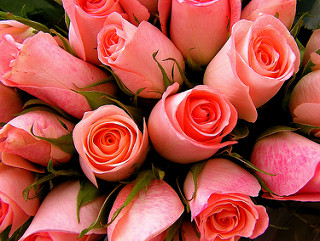

In [8]:
PIL.Image.open(str(roses[8]))

In [9]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*'))
}

In [10]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [11]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [12]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [13]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(240, 179, 3)

In [14]:
cv2.resize(img, (180, 180)).shape

(180, 180, 3)

In [15]:
x, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [16]:
x = np.array(x)
y = np.array(y)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [18]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [19]:
num_classes = 5

model = keras.models.Sequential([
  keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  keras.layers.MaxPooling2D(),
  keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  keras.layers.MaxPooling2D(),
  keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  keras.layers.MaxPooling2D(),
    
  keras.layers.Flatten(),
  keras.layers.Dense(200, activation='relu'),
  keras.layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=10)

Epoch 1/10
86/86 [==============================] - 17s 38ms/step - loss: 1.4101 - accuracy: 0.4030
Epoch 2/10
86/86 [==============================] - 3s 39ms/step - loss: 1.0280 - accuracy: 0.6039
Epoch 3/10
86/86 [==============================] - 3s 36ms/step - loss: 0.7818 - accuracy: 0.7060
Epoch 4/10
86/86 [==============================] - 3s 34ms/step - loss: 0.5409 - accuracy: 0.8031
Epoch 5/10
86/86 [==============================] - 3s 34ms/step - loss: 0.3429 - accuracy: 0.8819
Epoch 6/10
86/86 [==============================] - 3s 34ms/step - loss: 0.2028 - accuracy: 0.9382
Epoch 7/10
86/86 [==============================] - 3s 36ms/step - loss: 0.1237 - accuracy: 0.9644
Epoch 8/10
86/86 [==============================] - 3s 31ms/step - loss: 0.0692 - accuracy: 0.9800
Epoch 9/10
86/86 [==============================] - 3s 32ms/step - loss: 0.0516 - accuracy: 0.9869
Epoch 10/10
86/86 [==============================] - 3s 30ms/step - loss: 0.0255 - accuracy: 0.9938


In [20]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 2s 28ms/step - loss: 2.5381 - accuracy: 0.6166


[2.5381038188934326, 0.6165577173233032]

## We see that train accuracy is very high (99%), the test accuracy is low (61%) indicating overfitting.

In [21]:
predictions = model.predict(X_test_scaled)
predictions

29/29 [==============================] - 1s 14ms/step


array([[  5.3455677 ,  26.557842  ,   7.1948776 , -24.775414  ,
         -4.1603823 ],
       [  7.3758802 ,   2.3363209 ,  -5.509962  ,  -8.7649    ,
          3.0713398 ],
       [  1.2436703 ,   0.7260969 ,  18.218616  , -10.866688  ,
         -6.14613   ],
       ...,
       [ -2.4310868 ,   3.1368134 , -10.224812  ,   2.5744998 ,
          2.4832764 ],
       [ -3.0141962 ,   4.2729974 ,   3.022566  ,   1.0804362 ,
         -5.1804624 ],
       [ -0.473018  ,  -4.946246  ,  -0.83774424,   4.70966   ,
          0.8227282 ]], dtype=float32)

In [22]:
score = tf.nn.softmax(predictions[565])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([2.23029125e-02, 9.66648638e-01, 1.08675035e-02, 1.87555884e-07,
       1.80806033e-04], dtype=float32)>

In [23]:
np.argmax(score)

1

In [24]:
y_test[565]

4

In [25]:
img_height = 180
img_width = 180

data_augmentation = keras.Sequential(
  [
    keras.layers.experimental.preprocessing.RandomFlip(
      "horizontal",
        input_shape=(img_height, img_width, 3)
    ),
      
    keras.layers.experimental.preprocessing.RandomRotation(0.1),
    keras.layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

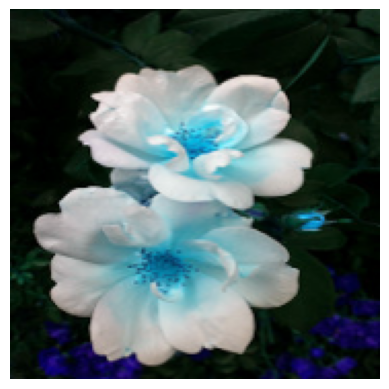

In [26]:
plt.axis('off')
plt.imshow(x[0])

(-0.5, 179.5, 179.5, -0.5)

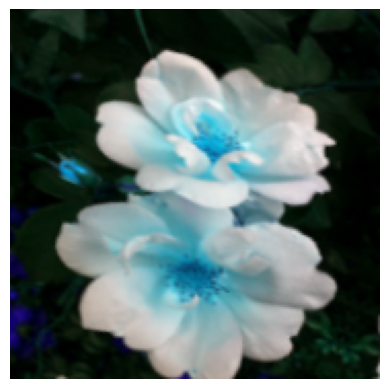

In [28]:
# plt.axis('off')
# plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))
plt.imshow(data_augmentation(x[0:1])[0].numpy().astype("uint8"))
plt.axis('off')

In [29]:
model = keras.models.Sequential([
    data_augmentation,
    keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),

    keras.layers.Dropout(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(200, activation='relu'),
    keras.layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(X_train_scaled, y_train, epochs=10)              

Epoch 1/10
86/86 [==============================] - 28s 283ms/step - loss: 1.3074 - accuracy: 0.4502
Epoch 2/10
86/86 [==============================] - 24s 284ms/step - loss: 1.0190 - accuracy: 0.6036
Epoch 3/10
86/86 [==============================] - 25s 287ms/step - loss: 0.9284 - accuracy: 0.6355
Epoch 4/10
86/86 [==============================] - 24s 282ms/step - loss: 0.8597 - accuracy: 0.6664
Epoch 5/10
86/86 [==============================] - 25s 285ms/step - loss: 0.7836 - accuracy: 0.7028
Epoch 6/10
86/86 [==============================] - 24s 282ms/step - loss: 0.7187 - accuracy: 0.7253
Epoch 7/10
86/86 [==============================] - 24s 275ms/step - loss: 0.6843 - accuracy: 0.7409
Epoch 8/10
86/86 [==============================] - 21s 243ms/step - loss: 0.6727 - accuracy: 0.7511
Epoch 9/10
86/86 [==============================] - 21s 242ms/step - loss: 0.5983 - accuracy: 0.7722
Epoch 10/10
86/86 [==============================] - 21s 241ms/step - loss: 0.5656 - accura

In [30]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 1s 17ms/step - loss: 0.8035 - accuracy: 0.7059


[0.8035028576850891, 0.7058823704719543]

## Here we can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 70%